In [1]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

print("Environment variables set")

Environment variables set


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
def compute_features(x1, m1, x2, m2, l=1.0):
    """
    Прямая задача для упрощённой постановки.

    Вход:
        x1, m1 — координата и масса первой точки на ребре e1
        x2, m2 — координата и масса второй точки на ребре e2
        l      — длина каждой нити, в работе берём l = 1

    Выход:
        X — входной вектор нейросети из 11 признаков
        Y — истинный вектор параметров: (x1, m1, x2, m2)
    """

    if not (0 < x1 < l):
        raise ValueError("x1 должен быть внутри интервала (0, l)")
    if not (0 < x2 < l):
        raise ValueError("x2 должен быть внутри интервала (0, l)")
    if not (m1 > 0 and m2 > 0):
        raise ValueError("Массы должны быть положительными")

    # Коэффициенты из вывода прямой задачи
    a1 = 1.0 / x1
    a2 = 1.0 / x2
    a3 = 1.0 / l

    b1 = 1.0 / (l - x1)
    b2 = 1.0 / (l - x2)

    S = a1 + a2 + a3

    # Матрица жёсткости после исключения безмассовой вершины V0
    K = np.array([
        [a1 + b1 - (a1 * a1) / S, -(a1 * a2) / S],
        [-(a1 * a2) / S, a2 + b2 - (a2 * a2) / S]
    ], dtype=np.float64)

    # Матрица масс диагональная: M = diag(m1, m2)
    inv_sqrt_M = np.diag([1.0 / np.sqrt(m1), 1.0 / np.sqrt(m2)])

    # Переход к симметричной задаче:
    # M^{-1/2} K M^{-1/2} q = lambda q
    C = inv_sqrt_M @ K @ inv_sqrt_M

    lambdas, q_vectors = np.linalg.eigh(C)

    # Сортируем собственные значения по возрастанию
    idx = np.argsort(lambdas)
    lambdas = lambdas[idx]
    q_vectors = q_vectors[:, idx]

    if np.any(lambdas <= 0):
        raise ValueError("Получены неположительные собственные значения")

    omega1 = np.sqrt(lambdas[0])
    omega2 = np.sqrt(lambdas[1])

    lambda1 = lambdas[0]
    lambda2 = lambdas[1]

    # Собственные формы в координатах A1, A2
    A_vectors = inv_sqrt_M @ q_vectors

    theta_all = []

    for k in range(2):
        A1 = A_vectors[0, k]
        A2 = A_vectors[1, k]

        # Амплитуда в центральной вершине V0
        A0 = (a1 * A1 + a2 * A2) / S

        # Углы малых наклонов считаем пропорциональными наклонам участков у границ
        theta1 = -b1 * A1
        theta2 = -b2 * A2
        theta3 = -a3 * A0

        theta = np.array([theta1, theta2, theta3], dtype=np.float64)

        # Нормировка, чтобы форма не зависела от масштаба амплитуды
        theta = theta / np.linalg.norm(theta)

        # Исправляем произвольный знак собственной формы
        main_index = np.argmax(np.abs(theta))
        if theta[main_index] < 0:
            theta = -theta

        theta_all.extend(theta.tolist())

    X = np.array([
        omega1,
        omega2,
        lambda1,
        lambda2,
        omega2 / omega1,
        theta_all[0],
        theta_all[1],
        theta_all[2],
        theta_all[3],
        theta_all[4],
        theta_all[5]
    ], dtype=np.float64)

    Y = np.array([x1, m1, x2, m2], dtype=np.float64)

    return X, Y

In [4]:
X_example, Y_example = compute_features(
    x1=0.30,
    m1=2.00,
    x2=0.70,
    m2=3.00,
    l=1.0
)

print("X =", X_example)
print("Размер X:", X_example.shape)

print("Y =", Y_example)
print("Размер Y:", Y_example.shape)

X = [ 1.05099363  1.3346967   1.10458761  1.78141528  1.26993795  0.47701845
  0.84086998  0.25571681 -0.43424416  0.89413403 -0.1093451 ]
Размер X: (11,)
Y = [0.3 2.  0.7 3. ]
Размер Y: (4,)


In [5]:
def generate_dataset(
    n_samples=10000,
    l=1.0,
    eps=0.05,
    m_min=0.1,
    m_max=5.0,
    noise_level=0.00,
    random_state=42
):
    """
    Генерация синтетической обучающей выборки.

    n_samples   — число объектов
    l           — длина нити
    eps         — отступ от концов нити, чтобы не брать x слишком близко к 0 и l
    m_min       — минимальная масса
    m_max       — максимальная масса
    noise_level — уровень шума в признаках X
    """

    rng = np.random.default_rng(random_state)

    X_list = []
    Y_list = []

    bad_count = 0

    for _ in range(n_samples):
        x1 = rng.uniform(eps, l - eps)
        x2 = rng.uniform(eps, l - eps)

        m1 = rng.uniform(m_min, m_max)
        m2 = rng.uniform(m_min, m_max)

        try:
            X, Y = compute_features(x1, m1, x2, m2, l=l)

            if noise_level > 0:
                X_noisy = X.copy()

                # Малый относительный шум на спектральные признаки
                X_noisy[:5] = X_noisy[:5] * (1.0 + rng.normal(0.0, noise_level, size=5))

                # Малый аддитивный шум на углы
                X_noisy[5:] = X_noisy[5:] + rng.normal(0.0, noise_level, size=6)

                X = X_noisy

            X_list.append(X)
            Y_list.append(Y)

        except Exception:
            bad_count += 1

    X_array = np.array(X_list, dtype=np.float32)
    Y_array = np.array(Y_list, dtype=np.float32)

    return X_array, Y_array, bad_count


X, Y, bad_count = generate_dataset(
    n_samples=10000,
    l=1.0,
    eps=0.05,
    m_min=0.1,
    m_max=5.0,
    noise_level=0.00,
    random_state=42
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Плохих объектов:", bad_count)

X shape: (10000, 11)
Y shape: (10000, 4)
Плохих объектов: 0


In [6]:
feature_names = [
    "omega1",
    "omega2",
    "lambda1",
    "lambda2",
    "omega2_div_omega1",
    "theta1_mode1",
    "theta2_mode1",
    "theta3_mode1",
    "theta1_mode2",
    "theta2_mode2",
    "theta3_mode2"
]

target_names = [
    "x1",
    "m1",
    "x2",
    "m2"
]

df_X = pd.DataFrame(X, columns=feature_names)
df_Y = pd.DataFrame(Y, columns=target_names)

df = pd.concat([df_X, df_Y], axis=1)

df.head()

,omega1,omega2,lambda1,lambda2,omega2_div_omega1,theta1_mode1,theta2_mode1,theta3_mode1,theta1_mode2,theta2_mode2,theta3_mode2,x1,m1,x2,m2
0,0.873031,1.101028,0.762183,1.212263,1.261156,0.645446,0.723603,0.244536,0.974959,-0.222074,0.011772,0.746560,4.307130,0.444991,3.517103
1,0.842775,1.942854,0.710269,3.774681,2.305307,0.678468,0.570127,0.463289,-0.005994,0.999974,0.004109,0.134760,3.829585,0.928060,3.951715
2,0.745826,1.384221,0.556256,1.916069,1.855957,0.368895,0.874603,0.314621,0.841951,-0.344488,0.415266,0.165302,1.916910,0.455347,4.641149
3,1.251482,2.160029,1.566208,4.665726,1.725977,0.957730,0.237301,0.162607,-0.042180,0.997176,0.062141,0.629479,2.272730,0.790485,1.213470
4,0.760818,1.164283,0.578843,1.355555,1.530305,0.843546,0.414750,0.341193,0.787796,-0.531724,-0.310881,0.549126,4.155393,0.107436,3.195156


In [7]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=SEED
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=SEED
)

print("Train:", X_train.shape, Y_train.shape)
print("Val:  ", X_val.shape, Y_val.shape)
print("Test: ", X_test.shape, Y_test.shape)

Train: (7000, 11) (7000, 4)
Val:   (1500, 11) (1500, 4)
Test:  (1500, 11) (1500, 4)


In [8]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = x_scaler.transform(X_val).astype(np.float32)
X_test_scaled = x_scaler.transform(X_test).astype(np.float32)

Y_train_scaled = y_scaler.fit_transform(Y_train).astype(np.float32)
Y_val_scaled = y_scaler.transform(Y_val).astype(np.float32)
Y_test_scaled = y_scaler.transform(Y_test).astype(np.float32)

print("Среднее X_train_scaled:", X_train_scaled.mean(axis=0).round(3))
print("Стандартное отклонение X_train_scaled:", X_train_scaled.std(axis=0).round(3))

Среднее X_train_scaled: [-0.  0.  0. -0. -0. -0.  0. -0.  0.  0.  0.]
Стандартное отклонение X_train_scaled: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
batch_size = 128

train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(Y_train_scaled, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(Y_val_scaled, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(Y_test_scaled, dtype=torch.float32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [10]:
class PhysicsRegressionNet(nn.Module):
    def __init__(self, input_size=11, output_size=4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.net(x)


model = PhysicsRegressionNet(input_size=11, output_size=4).to(device)

model

PhysicsRegressionNet(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=64, bias=True)
    (12): ReLU()
    (13): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [11]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=150,
    learning_rate=0.001,
    weight_decay=0.0001,
    patience=20
):
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(1, epochs + 1):
        model.train()

        train_loss_sum = 0.0
        train_count = 0

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, Y_batch)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * X_batch.size(0)
            train_count += X_batch.size(0)

        train_loss = train_loss_sum / train_count

        model.eval()

        val_loss_sum = 0.0
        val_count = 0

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                predictions = model(X_batch)
                loss = criterion(predictions, Y_batch)

                val_loss_sum += loss.item() * X_batch.size(0)
                val_count += X_batch.size(0)

        val_loss = val_loss_sum / val_count

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss = {train_loss:.6f} | "
                f"val_loss = {val_loss:.6f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping на эпохе {epoch}")
            break

    model.load_state_dict(best_model_state)

    return model, history

In [12]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=150,
    learning_rate=0.001,
    weight_decay=0.0001,
    patience=20
)

Epoch 001 | train_loss = 0.283840 | val_loss = 0.070576
Epoch 010 | train_loss = 0.057008 | val_loss = 0.025498
Epoch 020 | train_loss = 0.046423 | val_loss = 0.019546
Epoch 030 | train_loss = 0.036573 | val_loss = 0.011420
Epoch 040 | train_loss = 0.034316 | val_loss = 0.012458
Epoch 050 | train_loss = 0.031700 | val_loss = 0.009440
Epoch 060 | train_loss = 0.030777 | val_loss = 0.009422
Epoch 070 | train_loss = 0.027730 | val_loss = 0.010219
Epoch 080 | train_loss = 0.027898 | val_loss = 0.008213
Early stopping на эпохе 82


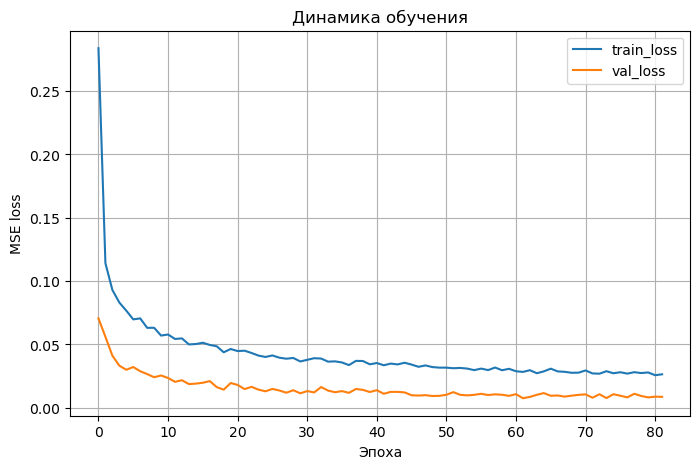

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Динамика обучения")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
def predict_scaled(model, X_scaled):
    model.eval()

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        predictions_scaled = model(X_tensor).cpu().numpy()

    return predictions_scaled


Y_pred_test_scaled = predict_scaled(model, X_test_scaled)

# Возвращаем предсказания из нормированного масштаба в физический
Y_pred_test = y_scaler.inverse_transform(Y_pred_test_scaled)

# Дополнительная физическая постобработка
Y_pred_test[:, 0] = np.clip(Y_pred_test[:, 0], 0.05, 0.95)
Y_pred_test[:, 1] = np.clip(Y_pred_test[:, 1], 0.1, 5.0)
Y_pred_test[:, 2] = np.clip(Y_pred_test[:, 2], 0.05, 0.95)
Y_pred_test[:, 3] = np.clip(Y_pred_test[:, 3], 0.1, 5.0)

Y_true_test = Y_test.copy()

Y_pred_test[:5]

array([[0.06070213, 4.650162  , 0.24231671, 4.1295404 ],
       [0.31050903, 3.761508  , 0.8514566 , 3.2557714 ],
       [0.888764  , 4.216421  , 0.45135078, 3.94312   ],
       [0.34497643, 3.9337971 , 0.8675641 , 1.7161154 ],
       [0.3405604 , 1.9822025 , 0.6211156 , 2.0145564 ]], dtype=float32)

In [15]:
mse_total = mean_squared_error(Y_true_test, Y_pred_test)
mae_total = mean_absolute_error(Y_true_test, Y_pred_test)

mse_by_target = mean_squared_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

mae_by_target = mean_absolute_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

print("Общий MSE:", mse_total)
print("Общий MAE:", mae_total)

metrics_df = pd.DataFrame({
    "Параметр": target_names,
    "MSE": mse_by_target,
    "MAE": mae_by_target
})

metrics_df

Общий MSE: 0.01355770044028759
Общий MAE: 0.05520083010196686


,Параметр,MSE,MAE
0,x1,0.000278,0.011956
1,m1,0.027452,0.099678
2,x2,0.000227,0.011508
3,m2,0.026273,0.097662


In [16]:
comparison_df = pd.DataFrame({
    "x1_true": Y_true_test[:, 0],
    "x1_pred": Y_pred_test[:, 0],

    "m1_true": Y_true_test[:, 1],
    "m1_pred": Y_pred_test[:, 1],

    "x2_true": Y_true_test[:, 2],
    "x2_pred": Y_pred_test[:, 2],

    "m2_true": Y_true_test[:, 3],
    "m2_pred": Y_pred_test[:, 3],
})

comparison_df.head(20)

,x1_true,x1_pred,m1_true,m1_pred,x2_true,x2_pred,m2_true,m2_pred
0,0.077202,0.060702,4.694882,4.650162,0.207871,0.242317,4.099820,4.129540
1,0.314439,0.310509,3.760723,3.761508,0.855994,0.851457,3.125715,3.255771
2,0.903015,0.888764,4.535833,4.216421,0.451310,0.451351,3.962055,3.943120
3,0.350274,0.344976,3.836407,3.933797,0.858530,0.867564,1.425621,1.716115
4,0.323091,0.340560,1.889554,1.982203,0.619135,0.621116,2.007446,2.014556
5,0.223040,0.210659,0.418516,0.458611,0.299691,0.317532,3.248772,3.184012
6,0.653817,0.606902,0.533245,0.595085,0.259287,0.258120,4.890839,4.853075
7,0.215466,0.210212,0.541540,0.696190,0.410754,0.418669,0.120808,0.133143
8,0.498953,0.502738,3.970214,4.069928,0.197747,0.206424,4.056152,4.126714
9,0.151445,0.146659,4.849217,4.810641,0.142167,0.146024,3.416890,3.540263


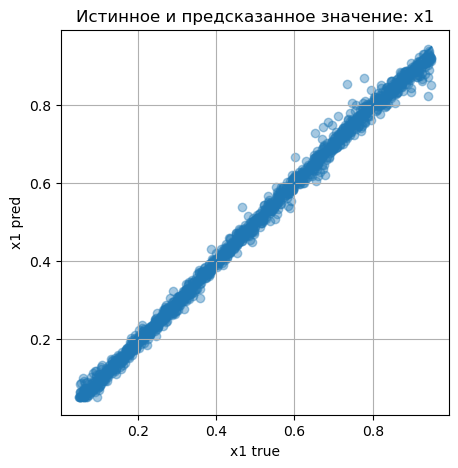

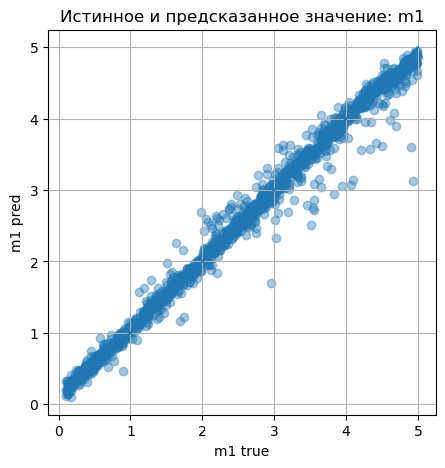

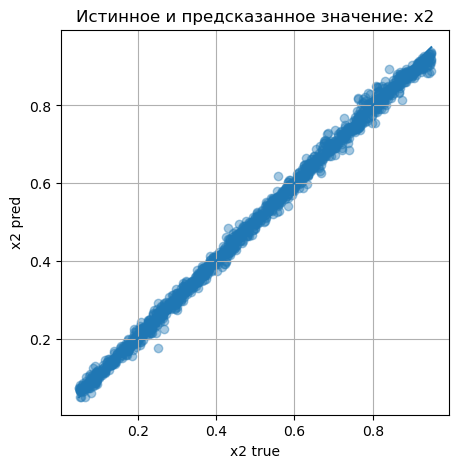

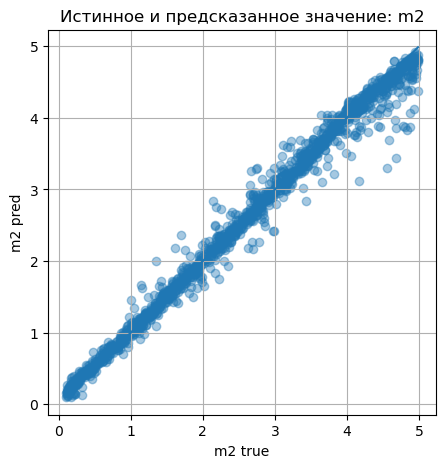

In [17]:
for i, name in enumerate(target_names):
    plt.figure(figsize=(5, 5))
    plt.scatter(Y_true_test[:, i], Y_pred_test[:, i], alpha=0.4)

    min_value = min(Y_true_test[:, i].min(), Y_pred_test[:, i].min())
    max_value = max(Y_true_test[:, i].max(), Y_pred_test[:, i].max())

    plt.plot([min_value, max_value], [min_value, max_value])
    plt.xlabel(f"{name} true")
    plt.ylabel(f"{name} pred")
    plt.title(f"Истинное и предсказанное значение: {name}")
    plt.grid(True)
    plt.show()

In [18]:
import pickle

torch.save(model.state_dict(), "physics_regression_net.pt")

with open("x_scaler.pkl", "wb") as file:
    pickle.dump(x_scaler, file)

with open("y_scaler.pkl", "wb") as file:
    pickle.dump(y_scaler, file)

print("Модель сохранена в physics_regression_net.pt")
print("Нормировщик X сохранён в x_scaler.pkl")
print("Нормировщик Y сохранён в y_scaler.pkl")

Модель сохранена в physics_regression_net.pt
Нормировщик X сохранён в x_scaler.pkl
Нормировщик Y сохранён в y_scaler.pkl


In [19]:
range_x = 0.95 - 0.05
range_m = 5.0 - 0.1

normalized_mae = np.array([
    mae_by_target[0] / range_x * 100,
    mae_by_target[1] / range_m * 100,
    mae_by_target[2] / range_x * 100,
    mae_by_target[3] / range_m * 100
])

extended_metrics_df = pd.DataFrame({
    "Параметр": target_names,
    "MSE": mse_by_target,
    "MAE": mae_by_target,
    "MAE, % от диапазона": normalized_mae
})

extended_metrics_df

,Параметр,MSE,MAE,"MAE, % от диапазона"
0,x1,0.000278,0.011956,1.328420
1,m1,0.027452,0.099678,2.034248
2,x2,0.000227,0.011508,1.278635
3,m2,0.026273,0.097662,1.993095


In [20]:
mass_error_df = pd.DataFrame({
    "m1_true": Y_true_test[:, 1],
    "m1_pred": Y_pred_test[:, 1],
    "m1_error": Y_pred_test[:, 1] - Y_true_test[:, 1],
    "m2_true": Y_true_test[:, 3],
    "m2_pred": Y_pred_test[:, 3],
    "m2_error": Y_pred_test[:, 3] - Y_true_test[:, 3],
})

mass_error_df.head()

,m1_true,m1_pred,m1_error,m2_true,m2_pred,m2_error
0,4.694882,4.650162,-0.044720,4.099820,4.129540,0.029721
1,3.760723,3.761508,0.000785,3.125715,3.255771,0.130056
2,4.535833,4.216421,-0.319412,3.962055,3.943120,-0.018935
3,3.836407,3.933797,0.097390,1.425621,1.716115,0.290494
4,1.889554,1.982203,0.092649,2.007446,2.014556,0.007111


In [21]:
def make_bins_report(true_values, pred_values, parameter_name):
    errors = pred_values - true_values

    bins = [0.1, 1.0, 2.0, 3.0, 4.0, 5.0]
    bin_labels = ["0.1-1.0", "1.0-2.0", "2.0-3.0", "3.0-4.0", "4.0-5.0"]

    temp_df = pd.DataFrame({
        "true": true_values,
        "pred": pred_values,
        "error": errors,
        "abs_error": np.abs(errors)
    })

    temp_df["bin"] = pd.cut(
        temp_df["true"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True
    )

    report = temp_df.groupby("bin").agg(
        count=("true", "count"),
        mean_true=("true", "mean"),
        mean_pred=("pred", "mean"),
        mean_error=("error", "mean"),
        mae=("abs_error", "mean")
    ).reset_index()

    report.insert(0, "parameter", parameter_name)

    return report


m1_bins_report = make_bins_report(
    Y_true_test[:, 1],
    Y_pred_test[:, 1],
    "m1"
)

m2_bins_report = make_bins_report(
    Y_true_test[:, 3],
    Y_pred_test[:, 3],
    "m2"
)

mass_bins_report = pd.concat(
    [m1_bins_report, m2_bins_report],
    axis=0
)

mass_bins_report

C:\TEMP\ipykernel_17128\1161698618.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = temp_df.groupby("bin").agg(
C:\TEMP\ipykernel_17128\1161698618.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = temp_df.groupby("bin").agg(


,parameter,bin,count,mean_true,mean_pred,mean_error,mae
0,m1,0.1-1.0,257,0.570338,0.651689,0.081350,0.091920
1,m1,1.0-2.0,285,1.495921,1.542120,0.046200,0.083183
2,m1,2.0-3.0,320,2.508557,2.540000,0.031443,0.093914
3,m1,3.0-4.0,320,3.527115,3.513321,-0.013794,0.109799
4,m1,4.0-5.0,318,4.510274,4.429397,-0.080878,0.116347
0,m2,0.1-1.0,258,0.517322,0.566576,0.049254,0.066280
1,m2,1.0-2.0,310,1.482850,1.502547,0.019697,0.074998
2,m2,2.0-3.0,290,2.531741,2.537831,0.006090,0.098685
3,m2,3.0-4.0,320,3.514544,3.523076,0.008532,0.089345
4,m2,4.0-5.0,322,4.482000,4.370490,-0.111511,0.151967


In [22]:
from sklearn.metrics import r2_score

abs_errors = np.abs(Y_pred_test - Y_true_test)

mse_by_target = mean_squared_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

mae_by_target = mean_absolute_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

rmse_by_target = np.sqrt(mse_by_target)

r2_by_target = r2_score(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

median_abs_error = np.median(abs_errors, axis=0)
p95_abs_error = np.percentile(abs_errors, 95, axis=0)
max_abs_error = np.max(abs_errors, axis=0)

range_x = 0.95 - 0.05
range_m = 5.0 - 0.1

ranges = np.array([range_x, range_m, range_x, range_m])

mae_percent_of_range = mae_by_target / ranges * 100
rmse_percent_of_range = rmse_by_target / ranges * 100
p95_percent_of_range = p95_abs_error / ranges * 100

extended_metrics_df = pd.DataFrame({
    "parameter": target_names,
    "MSE": mse_by_target,
    "RMSE": rmse_by_target,
    "MAE": mae_by_target,
    "Median AE": median_abs_error,
    "95% AE": p95_abs_error,
    "Max AE": max_abs_error,
    "R2": r2_by_target,
    "MAE, % range": mae_percent_of_range,
    "RMSE, % range": rmse_percent_of_range,
    "95% AE, % range": p95_percent_of_range
})

extended_metrics_df

,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,x1,0.000278,0.016677,0.011956,0.009296,0.031501,0.121549,0.995780,1.328420,1.853001,3.500113
1,m1,0.027452,0.165686,0.099678,0.065806,0.318942,1.804559,0.986098,2.034248,3.381347,6.509029
2,x2,0.000227,0.015080,0.011508,0.009194,0.030888,0.077414,0.996696,1.278634,1.675589,3.431971
3,m2,0.026273,0.162091,0.097662,0.059862,0.341181,1.255858,0.987036,1.993095,3.307974,6.962875


In [23]:
m1_true = Y_true_test[:, 1]
m1_pred = Y_pred_test[:, 1]

m2_true = Y_true_test[:, 3]
m2_pred = Y_pred_test[:, 3]

relative_error_m1 = np.abs(m1_pred - m1_true) / m1_true * 100
relative_error_m2 = np.abs(m2_pred - m2_true) / m2_true * 100

relative_mass_metrics_df = pd.DataFrame({
    "parameter": ["m1", "m2"],
    "Mean relative error, %": [
        relative_error_m1.mean(),
        relative_error_m2.mean()
    ],
    "Median relative error, %": [
        np.median(relative_error_m1),
        np.median(relative_error_m2)
    ],
    "95% relative error, %": [
        np.percentile(relative_error_m1, 95),
        np.percentile(relative_error_m2, 95)
    ],
    "Max relative error, %": [
        relative_error_m1.max(),
        relative_error_m2.max()
    ]
})

relative_mass_metrics_df

,parameter,"Mean relative error, %","Median relative error, %","95% relative error, %","Max relative error, %"
0,m1,7.384057,2.781358,28.837187,219.902298
1,m2,6.517628,2.686012,26.731390,138.464279


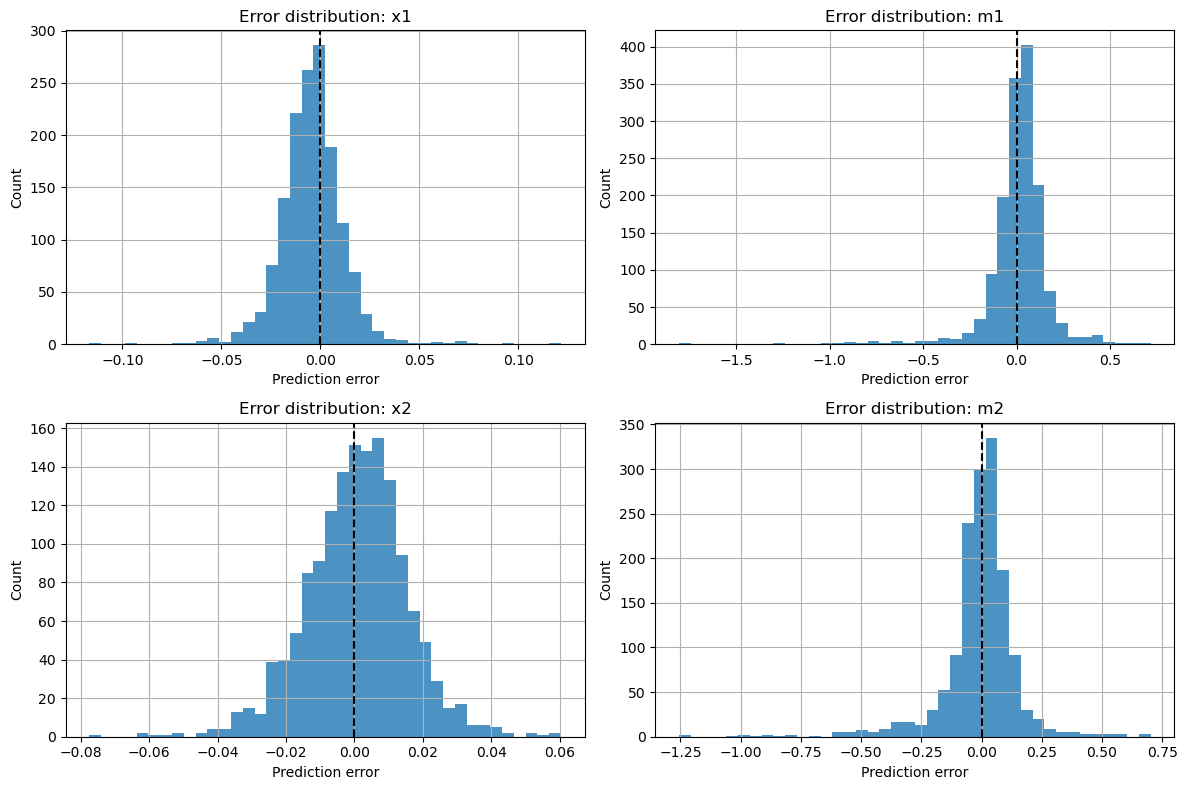

In [24]:
plt.figure(figsize=(12, 8))

for i, name in enumerate(target_names):
    plt.subplot(2, 2, i + 1)
    plt.hist(Y_pred_test[:, i] - Y_true_test[:, i], bins=40, alpha=0.8)
    plt.axvline(0, color="black", linestyle="--")
    plt.xlabel("Prediction error")
    plt.ylabel("Count")
    plt.title(f"Error distribution: {name}")
    plt.grid(True)

plt.tight_layout()
plt.show()

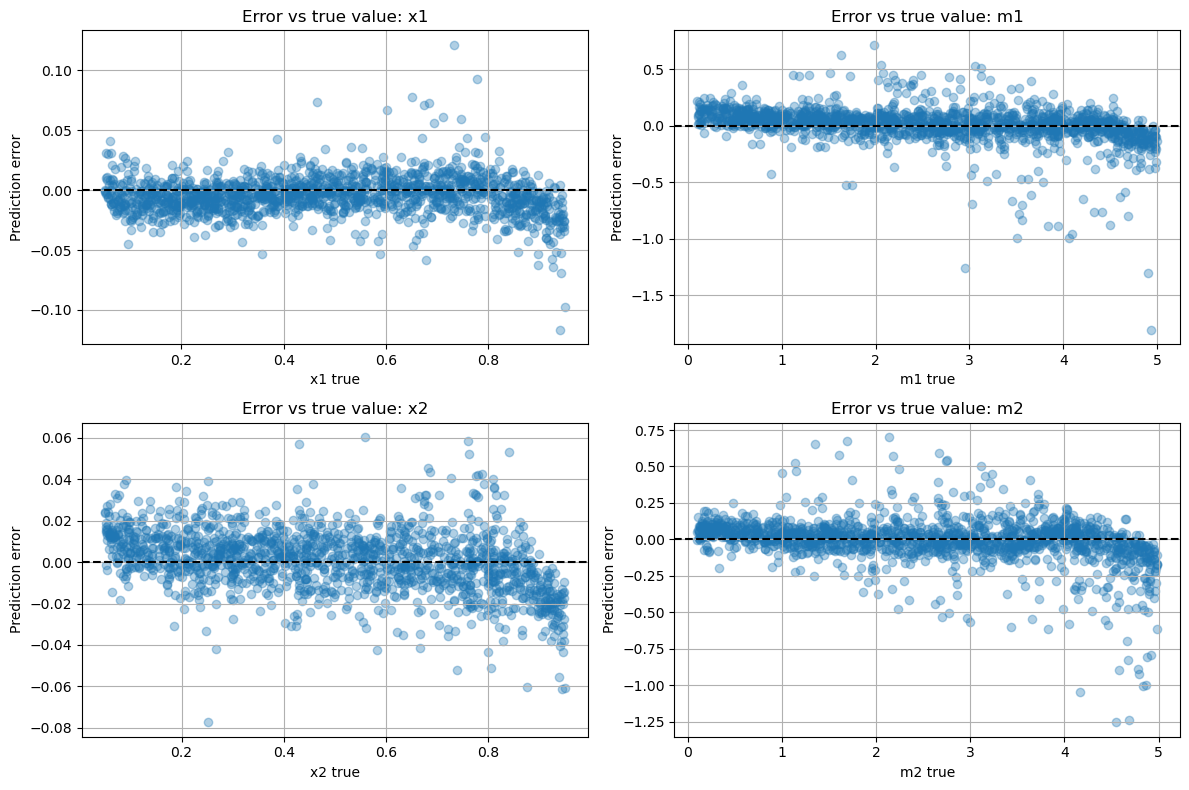

In [25]:
plt.figure(figsize=(12, 8))

for i, name in enumerate(target_names):
    errors = Y_pred_test[:, i] - Y_true_test[:, i]

    plt.subplot(2, 2, i + 1)
    plt.scatter(Y_true_test[:, i], errors, alpha=0.35)
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel(f"{name} true")
    plt.ylabel("Prediction error")
    plt.title(f"Error vs true value: {name}")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
def make_error_bins_report(true_values, pred_values, parameter_name, bins):
    errors = pred_values - true_values
    abs_errors = np.abs(errors)

    temp_df = pd.DataFrame({
        "true": true_values,
        "pred": pred_values,
        "error": errors,
        "abs_error": abs_errors
    })

    temp_df["bin"] = pd.cut(
        temp_df["true"],
        bins=bins,
        include_lowest=True
    )

    report = temp_df.groupby("bin", observed=False).agg(
        count=("true", "count"),
        mean_true=("true", "mean"),
        mean_pred=("pred", "mean"),
        mean_error=("error", "mean"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        p95_abs_error=("abs_error", lambda x: np.percentile(x, 95))
    ).reset_index()

    report.insert(0, "parameter", parameter_name)

    return report


x_bins = [0.05, 0.15, 0.30, 0.50, 0.70, 0.85, 0.95]
m_bins = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 4.5, 5.0]

x1_report = make_error_bins_report(Y_true_test[:, 0], Y_pred_test[:, 0], "x1", x_bins)
m1_report = make_error_bins_report(Y_true_test[:, 1], Y_pred_test[:, 1], "m1", m_bins)
x2_report = make_error_bins_report(Y_true_test[:, 2], Y_pred_test[:, 2], "x2", x_bins)
m2_report = make_error_bins_report(Y_true_test[:, 3], Y_pred_test[:, 3], "m2", m_bins)

bins_report_df = pd.concat(
    [x1_report, m1_report, x2_report, m2_report],
    axis=0
)

bins_report_df

,parameter,bin,count,mean_true,mean_pred,mean_error,mae,median_abs_error,p95_abs_error
0,x1,"(0.049, 0.15]",159,0.100226,0.095371,-0.004855,0.011697,0.010149,0.028696
1,x1,"(0.15, 0.3]",266,0.225971,0.218261,-0.007710,0.010764,0.009356,0.026064
2,x1,"(0.3, 0.5]",360,0.400613,0.397689,-0.002924,0.009430,0.007313,0.024382
3,x1,"(0.5, 0.7]",313,0.601110,0.601208,0.000098,0.011659,0.008873,0.036058
4,x1,"(0.7, 0.85]",240,0.771490,0.772488,0.000998,0.012867,0.010078,0.032483
5,x1,"(0.85, 0.95]",162,0.897736,0.880044,-0.017692,0.019003,0.014820,0.051869
0,m1,"(0.099, 0.5]",100,0.299056,0.401643,0.102587,0.106687,0.102906,0.221357
1,m1,"(0.5, 1.0]",157,0.743129,0.810953,0.067824,0.082515,0.074015,0.175329
2,m1,"(1.0, 2.0]",285,1.495921,1.542120,0.046200,0.083183,0.062084,0.209357
3,m1,"(2.0, 3.0]",320,2.508557,2.540000,0.031443,0.093914,0.061225,0.355257


In [27]:
X_reconstructed_list = []
valid_indices = []

for i in range(len(Y_pred_test)):
    x1_pred, m1_pred, x2_pred, m2_pred = Y_pred_test[i]

    try:
        X_rec, _ = compute_features(
            x1=x1_pred,
            m1=m1_pred,
            x2=x2_pred,
            m2=m2_pred,
            l=1.0
        )

        X_reconstructed_list.append(X_rec)
        valid_indices.append(i)

    except Exception:
        pass

X_reconstructed = np.array(X_reconstructed_list, dtype=np.float32)
X_original_valid = X_test[valid_indices]

feature_abs_error = np.abs(X_reconstructed - X_original_valid)

feature_mae = feature_abs_error.mean(axis=0)
feature_rmse = np.sqrt(((X_reconstructed - X_original_valid) ** 2).mean(axis=0))
feature_p95 = np.percentile(feature_abs_error, 95, axis=0)

feature_names = [
    "omega1",
    "omega2",
    "lambda1",
    "lambda2",
    "omega2 / omega1",
    "theta_1_mode_1",
    "theta_2_mode_1",
    "theta_3_mode_1",
    "theta_1_mode_2",
    "theta_2_mode_2",
    "theta_3_mode_2"
]

physics_check_df = pd.DataFrame({
    "feature": feature_names,
    "MAE": feature_mae,
    "RMSE": feature_rmse,
    "95% AE": feature_p95
})

print("Valid reconstructed samples:", len(valid_indices), "from", len(Y_pred_test))

physics_check_df

Valid reconstructed samples: 1500 from 1500


,feature,MAE,RMSE,95% AE
0,omega1,0.024082,0.067488,0.102960
1,omega2,0.148261,0.336702,0.767319
2,lambda1,0.088097,0.445983,0.354846
3,lambda2,1.138727,3.558044,6.207350
4,omega2 / omega1,0.117684,0.267474,0.560234
5,theta_1_mode_1,0.015012,0.044455,0.046199
6,theta_2_mode_1,0.013653,0.037598,0.037678
7,theta_3_mode_1,0.006295,0.009897,0.016725
8,theta_1_mode_2,0.028413,0.143360,0.061119
9,theta_2_mode_2,0.029834,0.146130,0.075108


In [28]:
import pickle
import torch

model = PhysicsRegressionNet(input_size=11, output_size=4).to(device)

model.load_state_dict(
    torch.load("physics_regression_net.pt", map_location=device)
)

model.eval()

with open("x_scaler.pkl", "rb") as file:
    x_scaler = pickle.load(file)

with open("y_scaler.pkl", "rb") as file:
    y_scaler = pickle.load(file)

print("Модель и нормировщики загружены")

Модель и нормировщики загружены


In [29]:
Y_log = Y.copy()

Y_log[:, 1] = np.log(Y_log[:, 1])
Y_log[:, 3] = np.log(Y_log[:, 3])

print("Original Y example:")
print(Y[:3])

print("Log-mass Y example:")
print(Y_log[:3])

Original Y example:
[[0.74656045 4.30713    0.4449906  3.5171034 ]
 [0.13475962 3.8295846  0.9280601  3.951715  ]
 [0.16530228 1.9169103  0.45534733 4.6411486 ]]
Log-mass Y example:
[[0.74656045 1.4602717  0.4449906  1.2576377 ]
 [0.13475962 1.3427564  0.9280601  1.3741497 ]
 [0.16530228 0.6507147  0.45534733 1.5349618 ]]


In [30]:
X_train_log, X_temp_log, Y_train_log, Y_temp_log = train_test_split(
    X,
    Y_log,
    test_size=0.30,
    random_state=SEED
)

X_val_log, X_test_log, Y_val_log, Y_test_log = train_test_split(
    X_temp_log,
    Y_temp_log,
    test_size=0.50,
    random_state=SEED
)

print("Train:", X_train_log.shape, Y_train_log.shape)
print("Val:  ", X_val_log.shape, Y_val_log.shape)
print("Test: ", X_test_log.shape, Y_test_log.shape)

Train: (7000, 11) (7000, 4)
Val:   (1500, 11) (1500, 4)
Test:  (1500, 11) (1500, 4)


In [31]:
x_scaler_log = StandardScaler()
y_scaler_log = StandardScaler()

X_train_log_scaled = x_scaler_log.fit_transform(X_train_log).astype(np.float32)
X_val_log_scaled = x_scaler_log.transform(X_val_log).astype(np.float32)
X_test_log_scaled = x_scaler_log.transform(X_test_log).astype(np.float32)

Y_train_log_scaled = y_scaler_log.fit_transform(Y_train_log).astype(np.float32)
Y_val_log_scaled = y_scaler_log.transform(Y_val_log).astype(np.float32)
Y_test_log_scaled = y_scaler_log.transform(Y_test_log).astype(np.float32)

In [32]:
batch_size = 256

train_dataset_log = TensorDataset(
    torch.tensor(X_train_log_scaled, dtype=torch.float32),
    torch.tensor(Y_train_log_scaled, dtype=torch.float32)
)

val_dataset_log = TensorDataset(
    torch.tensor(X_val_log_scaled, dtype=torch.float32),
    torch.tensor(Y_val_log_scaled, dtype=torch.float32)
)

train_loader_log = DataLoader(
    train_dataset_log,
    batch_size=batch_size,
    shuffle=True
)

val_loader_log = DataLoader(
    val_dataset_log,
    batch_size=batch_size,
    shuffle=False
)

In [33]:
class PhysicsRegressionNetSmall(nn.Module):
    def __init__(self, input_size=11, output_size=4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, output_size)
        )

    def forward(self, x):
        return self.net(x)


model_log = PhysicsRegressionNetSmall(input_size=11, output_size=4).to(device)

model_log

PhysicsRegressionNetSmall(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=4, bias=True)
  )
)

In [34]:
model_log, history_log = train_model(
    model=model_log,
    train_loader=train_loader_log,
    val_loader=val_loader_log,
    epochs=200,
    learning_rate=0.001,
    weight_decay=0.0001,
    patience=30
)

Epoch 001 | train_loss = 0.889150 | val_loss = 0.668916
Epoch 010 | train_loss = 0.052937 | val_loss = 0.046987
Epoch 020 | train_loss = 0.022330 | val_loss = 0.021216
Epoch 030 | train_loss = 0.012930 | val_loss = 0.012120
Epoch 040 | train_loss = 0.009152 | val_loss = 0.008699
Epoch 050 | train_loss = 0.007390 | val_loss = 0.008208
Epoch 060 | train_loss = 0.005819 | val_loss = 0.006295
Epoch 070 | train_loss = 0.005188 | val_loss = 0.005370
Epoch 080 | train_loss = 0.004315 | val_loss = 0.004856
Epoch 090 | train_loss = 0.004054 | val_loss = 0.004671
Epoch 100 | train_loss = 0.003596 | val_loss = 0.004564
Epoch 110 | train_loss = 0.003677 | val_loss = 0.004075
Epoch 120 | train_loss = 0.003251 | val_loss = 0.004320
Epoch 130 | train_loss = 0.003142 | val_loss = 0.004262
Epoch 140 | train_loss = 0.002816 | val_loss = 0.003528
Epoch 150 | train_loss = 0.002507 | val_loss = 0.003620
Epoch 160 | train_loss = 0.002365 | val_loss = 0.003387
Epoch 170 | train_loss = 0.002474 | val_loss = 0

In [35]:
Y_pred_test_log_scaled = predict_scaled(model_log, X_test_log_scaled)

Y_pred_test_log = y_scaler_log.inverse_transform(Y_pred_test_log_scaled)

Y_pred_test_log_original = Y_pred_test_log.copy()
Y_true_test_log_original = Y_test_log.copy()

Y_pred_test_log_original[:, 1] = np.exp(Y_pred_test_log_original[:, 1])
Y_pred_test_log_original[:, 3] = np.exp(Y_pred_test_log_original[:, 3])

Y_true_test_log_original[:, 1] = np.exp(Y_true_test_log_original[:, 1])
Y_true_test_log_original[:, 3] = np.exp(Y_true_test_log_original[:, 3])

Y_pred_test_log_original[:, 0] = np.clip(Y_pred_test_log_original[:, 0], 0.05, 0.95)
Y_pred_test_log_original[:, 1] = np.clip(Y_pred_test_log_original[:, 1], 0.1, 5.0)
Y_pred_test_log_original[:, 2] = np.clip(Y_pred_test_log_original[:, 2], 0.05, 0.95)
Y_pred_test_log_original[:, 3] = np.clip(Y_pred_test_log_original[:, 3], 0.1, 5.0)

Y_true_test = Y_true_test_log_original
Y_pred_test = Y_pred_test_log_original

Y_pred_test[:5]

array([[0.06909804, 4.4515443 , 0.21729274, 3.8778777 ],
       [0.30744725, 3.6761234 , 0.85442495, 3.0936282 ],
       [0.9015221 , 4.569705  , 0.45045674, 3.9232924 ],
       [0.3432626 , 3.598947  , 0.8574529 , 1.441776  ],
       [0.3231657 , 1.9576728 , 0.62715185, 2.0689635 ]], dtype=float32)

In [38]:
from sklearn.metrics import r2_score

abs_errors = np.abs(Y_pred_test - Y_true_test)

mse_by_target = mean_squared_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

mae_by_target = mean_absolute_error(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

rmse_by_target = np.sqrt(mse_by_target)

r2_by_target = r2_score(
    Y_true_test,
    Y_pred_test,
    multioutput="raw_values"
)

median_abs_error = np.median(abs_errors, axis=0)
p95_abs_error = np.percentile(abs_errors, 95, axis=0)
max_abs_error = np.max(abs_errors, axis=0)

range_x = 0.95 - 0.05
range_m = 5.0 - 0.1

ranges = np.array([range_x, range_m, range_x, range_m])

mae_percent_of_range = mae_by_target / ranges * 100
rmse_percent_of_range = rmse_by_target / ranges * 100
p95_percent_of_range = p95_abs_error / ranges * 100

extended_metrics_df = pd.DataFrame({
    "parameter": target_names,
    "MSE": mse_by_target,
    "RMSE": rmse_by_target,
    "MAE": mae_by_target,
    "Median AE": median_abs_error,
    "95% AE": p95_abs_error,
    "Max AE": max_abs_error,
    "R2": r2_by_target,
    "MAE, % range": mae_percent_of_range,
    "RMSE, % range": rmse_percent_of_range,
    "95% AE, % range": p95_percent_of_range
})

extended_metrics_df

,parameter,MSE,RMSE,MAE,Median AE,95% AE,Max AE,R2,"MAE, % range","RMSE, % range","95% AE, % range"
0,x1,0.000115,0.010701,0.007234,0.005432,0.018856,0.088777,0.998263,0.803788,1.189004,2.095121
1,m1,0.018645,0.136545,0.081012,0.047977,0.265568,1.549072,0.990558,1.653309,2.786638,5.419755
2,x2,0.000102,0.010105,0.007043,0.005204,0.019708,0.067675,0.998516,0.782540,1.122740,2.189728
3,m2,0.012896,0.113560,0.071170,0.042107,0.231556,1.012845,0.993637,1.452451,2.317552,4.725631


In [39]:
m1_true = Y_true_test[:, 1]
m1_pred = Y_pred_test[:, 1]

m2_true = Y_true_test[:, 3]
m2_pred = Y_pred_test[:, 3]

relative_error_m1 = np.abs(m1_pred - m1_true) / m1_true * 100
relative_error_m2 = np.abs(m2_pred - m2_true) / m2_true * 100

relative_mass_metrics_df = pd.DataFrame({
    "parameter": ["m1", "m2"],
    "Mean relative error, %": [
        relative_error_m1.mean(),
        relative_error_m2.mean()
    ],
    "Median relative error, %": [
        np.median(relative_error_m1),
        np.median(relative_error_m2)
    ],
    "95% relative error, %": [
        np.percentile(relative_error_m1, 95),
        np.percentile(relative_error_m2, 95)
    ],
    "Max relative error, %": [
        relative_error_m1.max(),
        relative_error_m2.max()
    ]
})

relative_mass_metrics_df

,parameter,"Mean relative error, %","Median relative error, %","95% relative error, %","Max relative error, %"
0,m1,3.255301,2.173593,9.529557,39.923458
1,m2,3.005758,2.086518,8.379052,37.852333


In [40]:
def make_error_bins_report(true_values, pred_values, parameter_name, bins):
    errors = pred_values - true_values
    abs_errors = np.abs(errors)

    temp_df = pd.DataFrame({
        "true": true_values,
        "pred": pred_values,
        "error": errors,
        "abs_error": abs_errors
    })

    temp_df["bin"] = pd.cut(
        temp_df["true"],
        bins=bins,
        include_lowest=True
    )

    report = temp_df.groupby("bin", observed=False).agg(
        count=("true", "count"),
        mean_true=("true", "mean"),
        mean_pred=("pred", "mean"),
        mean_error=("error", "mean"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        p95_abs_error=("abs_error", lambda x: np.percentile(x, 95))
    ).reset_index()

    report.insert(0, "parameter", parameter_name)

    return report


m_bins = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 4.5, 5.0]

m1_report = make_error_bins_report(
    Y_true_test[:, 1],
    Y_pred_test[:, 1],
    "m1",
    m_bins
)

m2_report = make_error_bins_report(
    Y_true_test[:, 3],
    Y_pred_test[:, 3],
    "m2",
    m_bins
)

mass_bins_report_df = pd.concat(
    [m1_report, m2_report],
    axis=0
)

mass_bins_report_df

,parameter,bin,count,mean_true,mean_pred,mean_error,mae,median_abs_error,p95_abs_error
0,m1,"(0.099, 0.5]",100,0.299056,0.303586,0.004529,0.011985,0.008122,0.035193
1,m1,"(0.5, 1.0]",157,0.743129,0.752324,0.009195,0.027835,0.016231,0.098612
2,m1,"(1.0, 2.0]",285,1.495921,1.506781,0.010860,0.049992,0.031673,0.140984
3,m1,"(2.0, 3.0]",320,2.508557,2.525336,0.016779,0.073937,0.051722,0.197888
4,m1,"(3.0, 4.0]",320,3.527115,3.523731,-0.003384,0.117580,0.081633,0.327797
5,m1,"(4.0, 4.5]",155,4.271733,4.249331,-0.022402,0.116410,0.089192,0.282707
6,m1,"(4.5, 5.0]",163,4.737108,4.651731,-0.085377,0.137259,0.100056,0.366170
0,m2,"(0.099, 0.5]",133,0.284199,0.279392,-0.004807,0.014806,0.009730,0.044985
1,m2,"(0.5, 1.0]",125,0.765365,0.758010,-0.007355,0.025881,0.018490,0.073573
2,m2,"(1.0, 2.0]",310,1.482850,1.474158,-0.008692,0.043066,0.028989,0.118583


In [41]:
import pickle
import torch

torch.save(model_log.state_dict(), "physics_regression_net_small_log.pt")

with open("x_scaler_log.pkl", "wb") as file:
    pickle.dump(x_scaler_log, file)

with open("y_scaler_log.pkl", "wb") as file:
    pickle.dump(y_scaler_log, file)

print("Облегченная модель сохранена в physics_regression_net_small_log.pt")
print("Нормировщик X сохранен в x_scaler_log.pkl")
print("Нормировщик Y сохранен в y_scaler_log.pkl")

Облегченная модель сохранена в physics_regression_net_small_log.pt
Нормировщик X сохранен в x_scaler_log.pkl
Нормировщик Y сохранен в y_scaler_log.pkl


In [42]:
model_info = {
    "model_name": "PhysicsRegressionNetSmall",
    "input_size": 11,
    "output_size": 4,
    "uses_log_mass": True,
    "target_names": target_names,
    "mass_columns": [1, 3],
    "x_range": [0.05, 0.95],
    "m_range": [0.1, 5.0],
    "architecture": "11-64-64-32-4",
    "loss": "MSELoss",
    "optimizer": "AdamW",
    "learning_rate": 0.001,
    "weight_decay": 0.0001
}

with open("physics_regression_net_small_log_info.pkl", "wb") as file:
    pickle.dump(model_info, file)

print("Описание модели сохранено в physics_regression_net_small_log_info.pkl")

Описание модели сохранено в physics_regression_net_small_log_info.pkl


In [43]:
checkpoint = {
    "model_state_dict": model_log.state_dict(),
    "x_scaler": x_scaler_log,
    "y_scaler": y_scaler_log,
    "model_info": model_info
}

torch.save(checkpoint, "physics_regression_net_small_log_checkpoint.pt")

print("Checkpoint сохранен в physics_regression_net_small_log_checkpoint.pt")

Checkpoint сохранен в physics_regression_net_small_log_checkpoint.pt
